# Week 4: Survival analysis on the narrowed candidate list

Runs Kaplan-Meier and Cox proportional hazards analysis on the 15 genes
narrowed down from Week 3's 40-gene shortlist -- filtered to genes that are
both selectively essential *and* tumor-enriched (the plan's own definition
of a leading candidate), then ranked by combined essentiality + tumor-
selectivity strength. Genes that didn't clear that bar aren't tested here;
see NOTES.md for why that's a deliberate choice, not an oversight.

The composite score that combines this with everything from Weeks 2-3 is
a separate, later step -- deliberately not done in this notebook, since
the weighting is a real judgment call worth talking through first.


In [1]:
# Load the narrowed 15-candidate list and build the TNBC patient survival table
import sys, re
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

from data_utils import (
    load_tcga_expression, load_tcga_clinical_cdes,
    get_tnbc_patient_barcodes, get_tnbc_survival_data,
    tcga_patient_barcode, tcga_is_tumor_sample,
)

candidates = pd.read_csv("../data/processed/depmap_tnbc_week4_candidates15.csv")
print(f"{len(candidates)} candidate genes")

cde = load_tcga_clinical_cdes()
survival = get_tnbc_survival_data(cde)
print(f"Survival data: {len(survival)} TNBC patients ({survival['event'].sum()} deaths, {(survival['event']==0).sum()} censored)")


15 candidate genes
Survival data: 143 TNBC patients (21 deaths, 122 censored)


## Matching each patient's survival record to their tumor's gene expression

Same Entrez-ID matching used in Weeks 2-3 (this 2016-vintage TCGA file's
gene symbols have drifted from DepMap's current ones for a meaningful
number of genes).


In [2]:
# Build one row per TNBC patient: survival data + this candidate's tumor expression, for every candidate gene at once
expr = load_tcga_expression()
tumor_cols = [c for c in expr.columns if tcga_is_tumor_sample(c)]
sample_to_patient = {c: tcga_patient_barcode(c) for c in tumor_cols}

raw_cols = pd.read_csv("../data/raw/depmap/CRISPR Gene Effect.csv", nrows=0).columns[1:]
symbol_to_entrez = {}
for col in raw_cols:
    m = re.match(r"^(.*) \((\d+)\)$", col)
    symbol_to_entrez[m.group(1)] = m.group(2)
entrez_to_rows = {}
for idx in expr.index:
    parts = idx.split("|")
    if len(parts) == 2:
        entrez_to_rows.setdefault(parts[1], []).append(idx)

gene_expr = {}
for gene in candidates["gene"]:
    entrez = symbol_to_entrez.get(gene)
    exp_rows = entrez_to_rows.get(entrez) if entrez else None
    if not exp_rows:
        continue
    vals = np.log2(expr.loc[exp_rows, tumor_cols].to_numpy().flatten().astype(float) + 1)
    gene_expr[gene] = pd.Series(vals, index=[sample_to_patient[c] for c in tumor_cols])

expr_df = pd.DataFrame(gene_expr)
# one tumor sample per patient in nearly every case; average duplicates if any patient has >1
expr_df = expr_df.groupby(level=0).mean()

analysis_df = survival.join(expr_df, how="inner")
print(f"Patients with both survival data and expression: {len(analysis_df)}")


Patients with both survival data and expression: 142


## Kaplan-Meier + log-rank test, per gene

For each gene: split these patients into "high expression" and "low
expression" at the median, plot both groups' survival curves, and run a
log-rank test -- does knowing which side of the median a patient's
expression falls on actually predict how long they survive?


In [3]:
# For each gene, split patients at the median expression and run a log-rank test comparing high vs. low survival
km_results = []
for gene in expr_df.columns:
    sub = analysis_df[["time", "event", gene]].dropna()
    median = sub[gene].median()
    high = sub[sub[gene] > median]
    low = sub[sub[gene] <= median]
    result = logrank_test(high["time"], low["time"], event_observed_A=high["event"], event_observed_B=low["event"])
    km_results.append((gene, len(sub), result.p_value))

km_df = pd.DataFrame(km_results, columns=["gene", "n_patients", "logrank_p"])
km_df["logrank_q"] = stats.false_discovery_control(km_df["logrank_p"], method="bh")
km_df = km_df.sort_values("logrank_p")
km_df


,gene,n_patients,logrank_p,logrank_q
5,SH3BP5L,142,0.076963,0.661012
7,CLTB,142,0.102774,0.661012
14,BIRC7,142,0.141501,0.661012
4,BROX,142,0.294492,0.661012
11,HPRT1,142,0.313701,0.661012
9,APRT,142,0.319178,0.661012
1,H2AC6,142,0.334260,0.661012
12,STK11IP,142,0.352540,0.661012
6,LY6E,142,0.418617,0.685972
0,IFI6,142,0.457315,0.685972


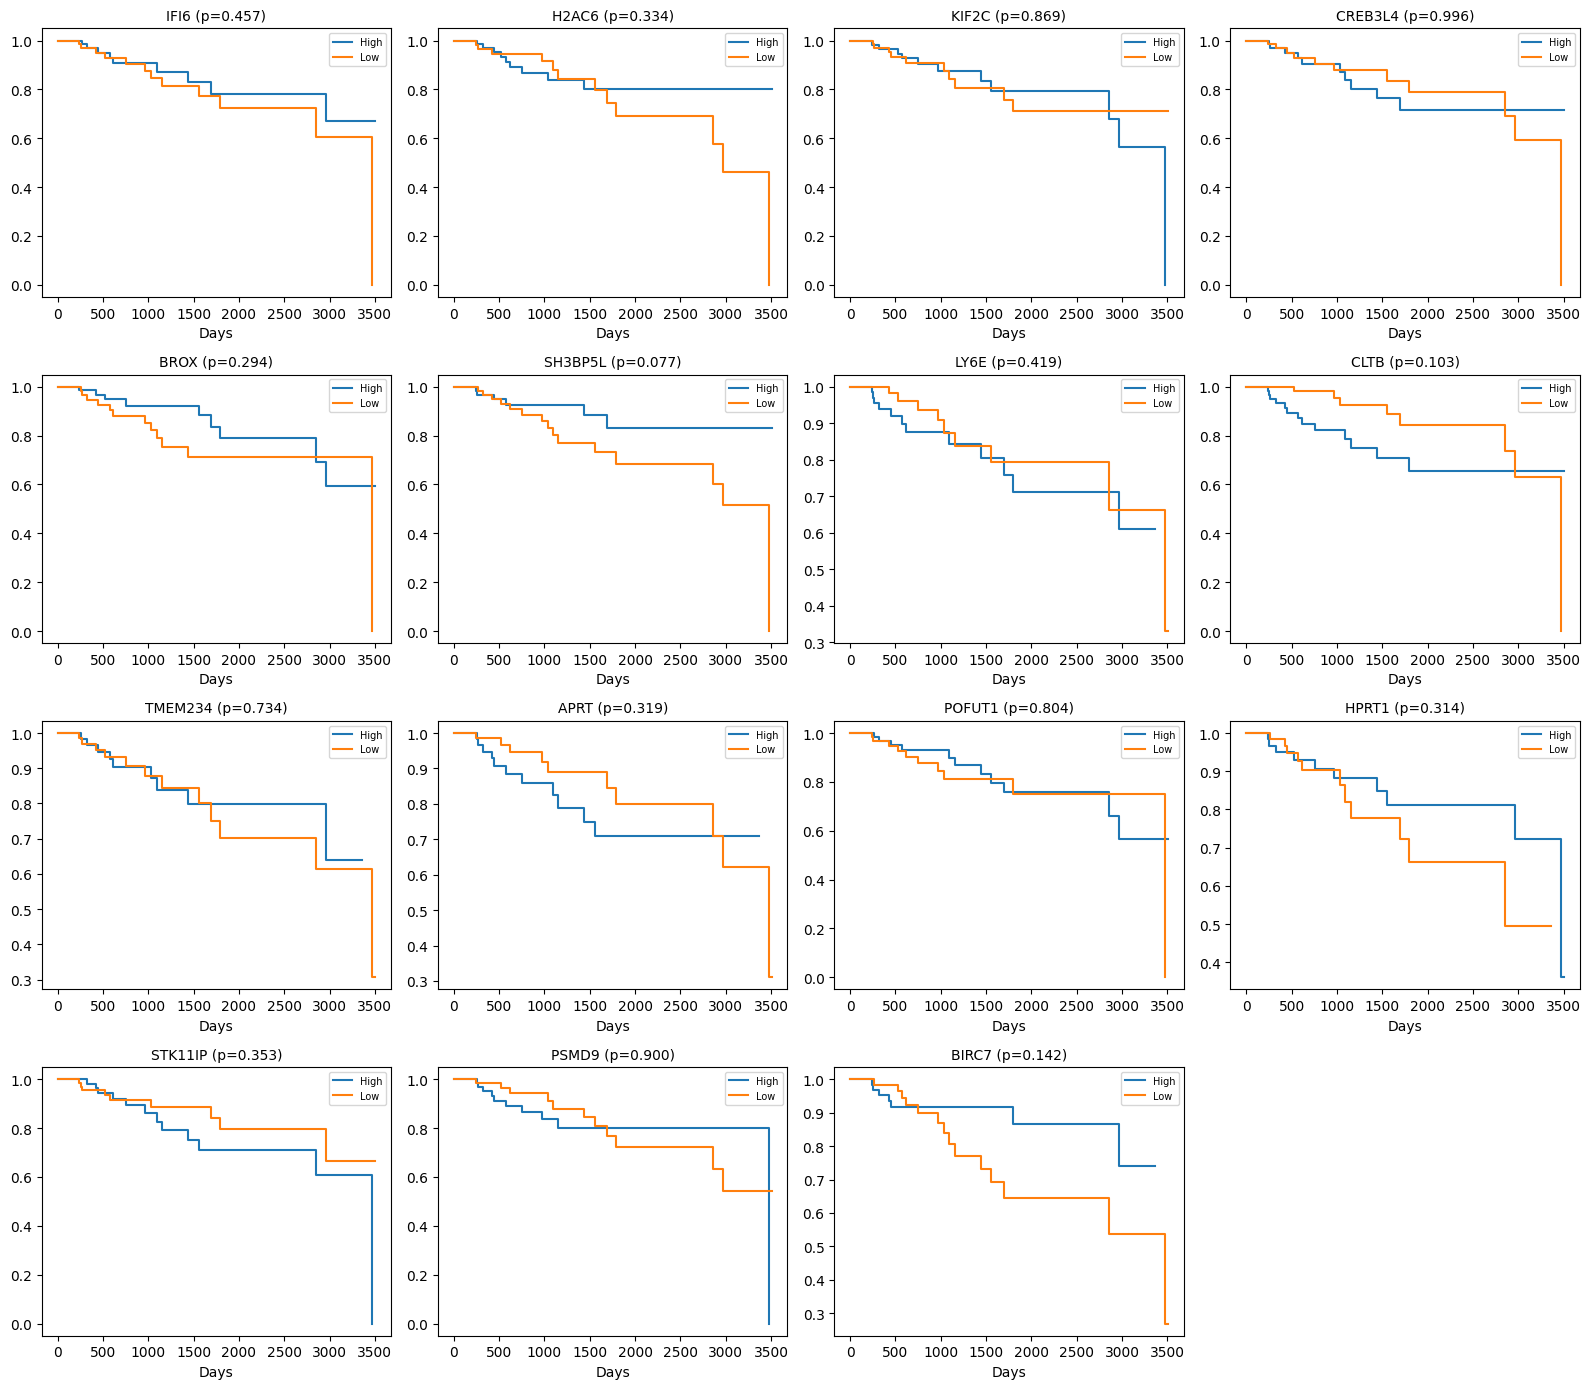

In [4]:
# Plot KM curves for all 15 candidates in a grid, so every gene's survival split is visible at a glance
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()
for ax, gene in zip(axes, expr_df.columns):
    sub = analysis_df[["time", "event", gene]].dropna()
    median = sub[gene].median()
    kmf_high = KaplanMeierFitter()
    kmf_low = KaplanMeierFitter()
    high = sub[sub[gene] > median]
    low = sub[sub[gene] <= median]
    kmf_high.fit(high["time"], high["event"], label="High")
    kmf_low.fit(low["time"], low["event"], label="Low")
    kmf_high.plot_survival_function(ax=ax, ci_show=False)
    kmf_low.plot_survival_function(ax=ax, ci_show=False)
    p = km_df.loc[km_df["gene"] == gene, "logrank_p"].values[0]
    ax.set_title(f"{gene} (p={p:.3f})", fontsize=10)
    ax.set_xlabel("Days")
    ax.legend(fontsize=7)
for ax in axes[len(expr_df.columns):]:
    ax.axis("off")
plt.tight_layout()
plt.show()


## Cox proportional hazards model, per gene

Kaplan-Meier's median split throws away information (a patient just barely
above the median counts the same as the most extreme outlier). Cox
regression uses each patient's actual continuous expression value instead,
and reports a **hazard ratio**: how much a one-unit increase in log2
expression multiplies the risk of death at any given moment, holding
survival time itself out of the equation. A hazard ratio above 1 means
higher expression is associated with worse survival; below 1 means better.
Run twice per gene -- unadjusted, and adjusted for age and tumor stage (the
plan's suggested covariates) -- so it's visible how much of any effect is
really about the gene versus just older/later-stage patients tending to
express it differently.


In [5]:
# For each gene, fit an unadjusted and an age/stage-adjusted Cox model on continuous expression
cox_results = []
for gene in expr_df.columns:
    sub = analysis_df[["time", "event", "age", "stage", gene]].dropna()

    cph_unadj = CoxPHFitter()
    cph_unadj.fit(sub[["time", "event", gene]], duration_col="time", event_col="event")
    hr_unadj = np.exp(cph_unadj.params_[gene])
    p_unadj = cph_unadj.summary.loc[gene, "p"]

    cph_adj = CoxPHFitter()
    cph_adj.fit(sub[["time", "event", "age", "stage", gene]], duration_col="time", event_col="event")
    hr_adj = np.exp(cph_adj.params_[gene])
    p_adj = cph_adj.summary.loc[gene, "p"]

    cox_results.append((gene, len(sub), hr_unadj, p_unadj, hr_adj, p_adj))

cox_df = pd.DataFrame(cox_results, columns=["gene", "n_patients", "hazard_ratio", "cox_p", "hazard_ratio_adj", "cox_p_adj"])
cox_df["cox_q"] = stats.false_discovery_control(cox_df["cox_p"], method="bh")
cox_df["cox_q_adj"] = stats.false_discovery_control(cox_df["cox_p_adj"], method="bh")
cox_df = cox_df.sort_values("cox_p")
cox_df


,gene,n_patients,hazard_ratio,cox_p,hazard_ratio_adj,cox_p_adj,cox_q,cox_q_adj
6,LY6E,139,1.615479,0.018897,1.735304,0.002414,0.283456,0.036211
11,HPRT1,139,0.503931,0.057299,0.694334,0.370618,0.377926,0.794182
5,SH3BP5L,139,0.474386,0.087710,0.614982,0.235528,0.377926,0.794182
13,PSMD9,139,1.986996,0.100780,2.432344,0.053369,0.377926,0.400269
4,BROX,139,0.793038,0.218705,0.848698,0.437936,0.656115,0.821130
12,STK11IP,139,1.409161,0.357218,1.065517,0.862217,0.805124,0.923804
7,CLTB,139,1.243125,0.375725,1.280285,0.316448,0.805124,0.794182
10,POFUT1,139,0.728698,0.471475,0.471249,0.186694,0.884017,0.794182
3,CREB3L4,139,1.124835,0.613130,1.105731,0.697556,0.958841,0.903093
9,APRT,139,1.130084,0.666211,1.152126,0.618279,0.958841,0.903093


## Reading the results honestly

**Kaplan-Meier: no gene clears FDR correction.** Every logrank_q is above
0.66 -- the simple median-split test doesn't find a statistically robust
survival difference for any of the 15 candidates in this cohort. Worth
naming directly rather than downplaying: this TNBC cohort only has **21
deaths** among 142 patients. Survival analysis's statistical power comes
almost entirely from the number of *events* (deaths), not the number of
patients -- 21 events is a genuinely small number to detect anything but a
very large effect, especially after a median split throws away information
by collapsing a continuous value into two buckets.

**Cox regression, adjusted for age and stage, finds one real signal:
`LY6E`.** Unadjusted, `LY6E`'s hazard ratio is 1.62 (higher expression ->
worse survival) at p=0.019 -- not quite enough to survive FDR correction
across 15 genes on its own (q=0.28). But adjusting for age and tumor stage
*strengthens* the result (HR 1.74, p=0.0024, **q=0.036 -- survives
correction**). That's a meaningful pattern, not a fluke: it means part of
the crude association was being diluted by age/stage differences between
patients, and controlling for them reveals a cleaner, stronger effect --
the opposite of what you'd expect if age/stage were driving a spurious
result. Combined with Week 2's independent literature validation and Week
3's tumor-overexpression finding, `LY6E` now has **real survival evidence
from this project's own data**, not just borrowed from outside sources.

**`KIF2C` shows no survival association here (cox_p=0.72) -- and that's
expected, not a contradiction.** This lines up exactly with the HPA
discrepancy investigated in Week 3: HPA's own single-cohort analysis of
`KIF2C` also came back "unprognostic," while the published literature that
*did* find a significant association pooled many independent cohorts for
far more statistical power than any single cohort (this one included) can
offer. A 142-patient, 21-event cohort was never likely to detect that
effect on its own -- this null result doesn't undermine `KIF2C`'s standing
as a candidate, it's simply consistent with what a dataset this size can
and can't show.


## Combining with Kaplan-Meier and saving

`data/processed/depmap_tnbc_week4_survival.csv` merges the KM log-rank
results with both Cox models onto the 15-candidate table -- the input
Week 4's composite-score discussion will work from.


In [6]:
# Merge KM and Cox results onto the 15-candidate table (both share an n_patients column, drop one copy)
survival_results = candidates.merge(km_df, on="gene").merge(cox_df.drop(columns="n_patients"), on="gene")
survival_results = survival_results.sort_values("cox_p")
survival_results.to_csv("../data/processed/depmap_tnbc_week4_survival.csv", index=False)

cols = ["gene", "n_patients", "logrank_p", "logrank_q", "hazard_ratio", "cox_p", "cox_q",
        "hazard_ratio_adj", "cox_p_adj", "cox_q_adj"]
survival_results[cols]

,gene,n_patients,logrank_p,logrank_q,hazard_ratio,cox_p,cox_q,hazard_ratio_adj,cox_p_adj,cox_q_adj
6,LY6E,142,0.418617,0.685972,1.615479,0.018897,0.283456,1.735304,0.002414,0.036211
11,HPRT1,142,0.313701,0.661012,0.503931,0.057299,0.377926,0.694334,0.370618,0.794182
5,SH3BP5L,142,0.076963,0.661012,0.474386,0.087710,0.377926,0.614982,0.235528,0.794182
13,PSMD9,142,0.899925,0.964206,1.986996,0.100780,0.377926,2.432344,0.053369,0.400269
4,BROX,142,0.294492,0.661012,0.793038,0.218705,0.656115,0.848698,0.437936,0.821130
12,STK11IP,142,0.352540,0.661012,1.409161,0.357218,0.805124,1.065517,0.862217,0.923804
7,CLTB,142,0.102774,0.661012,1.243125,0.375725,0.805124,1.280285,0.316448,0.794182
10,POFUT1,142,0.804432,0.964206,0.728698,0.471475,0.884017,0.471249,0.186694,0.794182
3,CREB3L4,142,0.995829,0.995829,1.124835,0.613130,0.958841,1.105731,0.697556,0.903093
9,APRT,142,0.319178,0.661012,1.130084,0.666211,0.958841,1.152126,0.618279,0.903093
